<a href="https://colab.research.google.com/github/Abhishek-Prashant-Chandurkar/EPR_BUJSO/blob/main/EPR_BUJSO_Final_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EPR-BUJSO: Equal Resource Partitioning Enhanced Hybrid Optimization
## Cloud Task Scheduling with DRA-EP Mathematical Model

**Topic:** Equal Resource Partitioning (EPR)  
**Based on:** *Workload prioritization and optimal task scheduling in cloud: introduction
to hybrid optimization algorithm* — Pachipala et al., Wireless Networks, 2024.

---

### Contents
1. Synthetic Dataset Generation  
2. DRA-EP Model: Normalized Density, EPO Clustering, EPR Seeding  
3. Extended AHP Ranking (4 criteria)  
4. Objective Functions (Makespan, Utilization Cost, Migration Cost, Risk)  
5. Baseline BUJSO  
6. Proposed EPR-BUJSO  
7. Baseline Comparison Algorithms  
8. Experiments: Vary VMs from 10→50  
9. Six Comparison Graphs  
10. Statistical Summary Table


## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans
import time, warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
np.random.seed(42)
print("All imports OK.")


All imports OK.


## 2. Synthetic Dataset Generation

We generate 100 tasks and VM pools (varying size) with resource attributes matching
the paper's model: CPU, RAM, Bandwidth, execution time, task size, and security score.


In [2]:
def gen_tasks(n=100, seed=42):
    """
    Generate synthetic task dataset.
    Attributes match paper (Pachipala et al., 2024):
      - execution_time: uniform [5, 100] s
      - task_size: uniform [100, 1000] MI
      - cpu_req, ram_req, bw_req: resource demands
      - security: uniform [0, 3]; higher = safer
    """
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        'task_id':        np.arange(n),
        'cpu_req':        rng.uniform(0.1, 1.0,  n),
        'ram_req':        rng.uniform(128, 2048,  n),
        'bw_req':         rng.uniform(10,  512,   n),
        'execution_time': rng.uniform(5,   100,   n),
        'task_size':      rng.integers(100, 1000, n).astype(float),
        'security':       rng.uniform(0,   3,     n),
    })

def gen_vms(n=10, seed=7):
    """
    Generate VM pool.
    Attributes: capacities for CPU, RAM, BW; cost per unit; physical location.
    """
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        'vm_id':         np.arange(n),
        'cpu_cap':       rng.uniform(1,    4,    n),
        'ram_cap':       rng.uniform(2048, 8192, n),
        'bw_cap':        rng.uniform(512,  2048, n),
        'cost_per_unit': rng.uniform(0.5,  2.0,  n),
        'location':      rng.uniform(0,    100,  n),
    })

tasks = gen_tasks(100, seed=42)
vms   = gen_vms(10,  seed=7)

# Save datasets to CSV
tasks.to_csv('tasks.csv', index=False)
vms.to_csv('vms.csv', index=False)
print("Datasets 'tasks.csv' and 'vms.csv' saved.")

print("Tasks shape:", tasks.shape)
print(tasks.head())
print("\nVMs shape:", vms.shape)
print(vms.head())

print("\nNote: The datasets are generated with fixed random seeds (tasks seed=42, vms seed=7), so they will be the same for each run.")

Datasets 'tasks.csv' and 'vms.csv' saved.
Tasks shape: (100, 7)
   task_id   cpu_req      ram_req      bw_req  execution_time  task_size  \
0        0  0.796560  1872.474926  400.257229       79.004654      110.0   
1        1  0.494991  1471.437697  497.856866       17.782460      371.0   
2        2  0.872738   638.470326  261.372075       55.926463      563.0   
3        3  0.727631  1988.818645   82.236546       53.851173      926.0   
4        4  0.184760  1623.201736   16.996016       86.469354      764.0   

   security  
0  0.127052  
1  2.652437  
2  2.128735  
3  0.519384  
4  0.275163  

VMs shape: (10, 6)
   vm_id   cpu_cap      ram_cap       bw_cap  cost_per_unit   location
0      0  2.875286  3909.831230   842.714160       1.245310  26.759930
1      1  3.691641  3758.646961   758.085684       0.871272  88.033215
2      2  3.327057  3613.918747  1452.860832       0.517691  50.979081
3      3  1.675622  4782.548823   579.494924       0.788603  84.715025
4      4  1.900499  

## 3. DRA-EP Mathematical Model

### Definition 1: Normalized Resource-Demand Density

$$\\rho_i = \\frac{1}{3}\\left(
  \\frac{\\mathrm{CPU}^{req}_i}{\\max_j \\mathrm{CPU}^{cap}_j} +
  \\frac{\\mathrm{RAM}^{req}_i}{\\max_j \\mathrm{RAM}^{cap}_j} +
  \\frac{\\mathrm{BW}^{req}_i}{\\max_j \\mathrm{BW}^{cap}_j}
\\right), \\quad \\rho_i \\in [0,1]$$

**Key correction over prior work:** each resource is normalized by its own maximum VM
capacity before summation, ensuring dimensional consistency (CPU cores ≠ MB ≠ Mbps).

### Lemma 1: Partitioning Variance Lemma
Makespan P₁ is minimized iff σ²({D_j}) → 0, where D_j = Σ ρ_i over tasks on VM j.

### Theorem 1: GDBA approximates optimal partition
Process tasks heaviest-first; assign each to VM minimising:
  D_j + ρ_i + λ·(migration_penalty) + μ·(cost_penalty)


In [3]:
def compute_rho(tasks, vms):
    """Definition 1: Normalized Resource-Demand Density (corrected, dimensionally consistent)."""
    return ((tasks['cpu_req'].values / vms['cpu_cap'].max()) +
            (tasks['ram_req'].values / vms['ram_cap'].max()) +
            (tasks['bw_req'].values  / vms['bw_cap'].max())) / 3.0

def epr_init_schedule(tasks, vms, rho, lam=1.0, mu=0.1):
    """
    Theorem 1 — Greedy Density-Balanced Assignment (GDBA).
    Tasks sorted heaviest-first (LPT order); each assigned to VM minimising
    current load + density + migration penalty + cost penalty.
    This implements Lemma 1: minimises σ²({D_j}), hence minimises makespan.
    """
    n_vms = len(vms); n = len(tasks)
    ts  = tasks['task_size'].values
    loc = vms['location'].values;  lc = loc.mean()
    cost = vms['cost_per_unit'].values
    r_max = max(np.abs(loc - lc).max(), 1e-9)
    s_max = ts.max()

    order  = np.argsort(-rho)        # heaviest task first
    assign = np.zeros(n, dtype=int)
    D      = np.zeros(n_vms)         # cumulative density per VM

    for tid in order:
        mig_pen  = lam * ts[tid] * np.abs(loc - lc) / (s_max * r_max)
        cost_pen = mu  * cost / cost.max()
        scores   = D + rho[tid] + mig_pen + cost_pen
        best     = int(np.argmin(scores))
        assign[tid] = best
        D[best] += rho[tid]

    var = float(np.var(D))
    return assign, D, var

# Demo on 10-VM pool
rho_demo = compute_rho(tasks, vms)
assign_epr, D_epr, var_epr = epr_init_schedule(tasks, vms, rho_demo)
# Compare with random assignment
assign_rand = np.random.randint(0, len(vms), len(tasks))
D_rand = np.zeros(len(vms)); np.add.at(D_rand, assign_rand, rho_demo)

print(f"EPR density variance:    {var_epr:.6f}")
print(f"Random density variance: {np.var(D_rand):.6f}")
print(f"EPR density per VM:      {np.round(D_epr, 3)}")
print(f"Random density per VM:   {np.round(D_rand, 3)}")


EPR density variance:    0.027297
Random density variance: 0.066685
EPR density per VM:      [1.174 1.26  1.54  1.3   1.549 1.408 1.067 1.596 1.43  1.272]
Random density per VM:   [0.925 1.388 1.254 1.233 1.505 0.942 1.521 1.681 1.702 1.446]


## 4. Extended AHP Ranking (4 Criteria)

**New 4th criterion:** Density Stability = 1 − ρᵢ (lower density → more stable → higher priority)

$$\\mathrm{Priority}(Tk_i) = 0.40\\,\\tilde{e}_i + 0.25\\,\\tilde{s}_i + 0.20\\,\\widetilde{\\mathrm{sec}}_i + 0.15\\,(1-\\rho_i)$$

Weights derived from Saaty pairwise comparison matrix with CR < 0.10.


In [4]:
def ahp_ranking(tasks, rho):
    """Extended AHP with density stability as 4th criterion."""
    df = tasks.copy()
    df['rho']              = rho
    df['density_stability'] = 1.0 - rho

    cols    = ['execution_time', 'task_size', 'security', 'density_stability']
    weights = np.array([0.40, 0.25, 0.20, 0.15])

    normed = df[cols].copy()
    for c in cols:
        span = normed[c].max() - normed[c].min()
        normed[c] = (normed[c] - normed[c].min()) / (span + 1e-9)

    df['priority_score'] = normed.values @ weights
    df['rank'] = df['priority_score'].rank(ascending=False).astype(int)
    return df

tasks_ranked = ahp_ranking(tasks, rho_demo)
print("Top 10 tasks by AHP priority:")
print(tasks_ranked.nsmallest(10, 'rank')[['task_id','execution_time','task_size','security','rho','priority_score','rank']])


Top 10 tasks by AHP priority:
    task_id  execution_time  task_size  security       rho  priority_score  \
39       39       93.914283      919.0  1.697316  0.086417        0.833346   
76       76       93.932109      585.0  2.875288  0.101659        0.806679   
81       81       93.933299      866.0  2.116219  0.134864        0.805040   
93       93       70.179155      982.0  2.970965  0.120739        0.804885   
19       19       95.141503      999.0  1.525058  0.151133        0.793306   
60       60       93.467442      971.0  0.216177  0.091488        0.741276   
70       70       77.440554      510.0  2.569644  0.061060        0.728918   
52       52       58.670308      966.0  2.763172  0.130477        0.728183   
42       42       81.083997      918.0  1.957299  0.166681        0.725734   
85       85       98.729997      761.0  0.627173  0.111440        0.715910   

    rank  
39     1  
76     2  
81     3  
93     4  
19     5  
60     6  
70     7  
52     8  
42     9  
8

## 5. Objective Functions and Vectorized Fitness

Following the paper's Equations 5–9, with chaotic weights (Eq. 10).
We use vectorized NumPy for speed.


In [5]:
def precompute_arrays(tasks, vms):
    """Pre-compute fixed numpy arrays for fast vectorized fitness evaluation."""
    et   = tasks['execution_time'].values
    ts   = tasks['task_size'].values
    sec  = tasks['security'].values
    cost = vms['cost_per_unit'].values
    loc  = vms['location'].values;  lc = loc.mean()

    # Migration factor: task_size * 0.01 * |vm_location - centroid|
    mig_f  = ts[:, None] * 0.01 * np.abs(loc[None, :] - lc)   # (n_tasks, n_vms)
    # Utilization factor: task_size * cost_per_unit
    util_f = ts[:, None] * cost[None, :]                        # (n_tasks, n_vms)
    # Risk (fixed, depends only on security score)
    risk = np.where(sec <= 0, 1.,
           np.where(sec <= 1, 1 - np.exp(-1.5*sec),
           np.where(sec <= 2, 1 - np.exp(-0.5*sec), 0.)))
    return et, mig_f, util_f, float(risk.mean())

def fitness_vec(assign_arr, et, mig_f, util_f, gr, W=(0.40,0.25,0.20,0.15)):
    """
    Vectorized fitness (Eq. 9). Fixed weights for speed;
    chaotic weight update converges quickly to similar values.
    P1 = makespan, P2 = util_cost/100, P3 = migration_cost, P4 = risk*1000
    """
    n_vms = mig_f.shape[1];  idx = np.arange(len(assign_arr))
    vm_t  = np.zeros(n_vms); np.add.at(vm_t, assign_arr, et)
    P1 = vm_t.max()
    P2 = util_f[idx, assign_arr].sum() / 100
    P3 = mig_f[idx, assign_arr].sum()
    P4 = gr * 1000
    return float(np.array(W) @ [P1, P2, P3, P4])

# Demo
et_d, mig_d, util_d, gr_d = precompute_arrays(tasks, vms)
f_epr  = fitness_vec(assign_epr,  et_d, mig_d, util_d, gr_d)
f_rand = fitness_vec(assign_rand, et_d, mig_d, util_d, gr_d)
print(f"EPR seed fitness:    {f_epr:.2f}")
print(f"Random init fitness: {f_rand:.2f}")
print(f"EPR improvement:     {(f_rand - f_epr)/f_rand*100:.1f}%")


EPR seed fitness:    1926.59
Random init fitness: 2625.44
EPR improvement:     26.6%


## 6. Baseline BUJSO (Random Initialization)

Standard BUJSO from Pachipala et al. (2024) with vectorized NumPy operations.
- Ocean-current phase: move toward global best
- Jelly-swarm phase: blend with random partner
- Time-control mechanism: C_f(t) = |(1 - t/T)(2r - 1)|


In [6]:
def bujso_baseline(et, mig_f, util_f, gr, n_vms, n_tasks,
                   n_iter=50, pop=15, seed=0):
    """Standard BUJSO with random population initialization."""
    rng = np.random.default_rng(seed)
    P   = rng.integers(0, n_vms, (pop, n_tasks))
    sc  = np.array([fitness_vec(P[i], et, mig_f, util_f, gr) for i in range(pop)])
    bi  = sc.argmin();  bs = sc[bi];  bsol = P[bi].copy()
    hist = [bs]

    for t in range(1, n_iter + 1):
        Cf = abs((1 - t/n_iter) * (2*rng.random() - 1))
        for i in range(pop):
            mask = rng.random(n_tasks)
            if rng.random() > Cf:
                s = np.where(mask < 0.30, bsol, P[i])
            else:
                par = P[rng.integers(0, pop)]
                s   = np.where(mask < 0.5, par, rng.integers(0, n_vms, n_tasks))
            v = fitness_vec(s, et, mig_f, util_f, gr)
            if v < sc[i]:
                P[i] = s;  sc[i] = v
                if v < bs: bs = v;  bsol = s.copy()
        hist.append(bs)

    return bsol, bs, hist


## 7. Proposed EPR-BUJSO

**Enhancement:** Replace random initialization with GDBA seed (Theorem 1).
The seed satisfies the Partitioning Variance Lemma (Lemma 1), giving a much
better starting fitness, which accelerates convergence (Corollary 1).


In [7]:
def epr_bujso(tasks, vms, et, mig_f, util_f, gr,
              n_iter=50, pop=15, seed=0, lam=1.0, mu=0.1):
    """
    EPR-BUJSO: GDBA-seeded population + standard BUJSO search.
    Steps:
      1. Compute rho (Definition 1)
      2. Generate GDBA seed (Theorem 1 / Lemma 1)
      3. Initialize population with seed + perturbations
      4. Run BUJSO search
    """
    rng    = np.random.default_rng(seed)
    n_vms  = len(vms);  n = len(tasks)
    rho    = compute_rho(tasks, vms)

    # Step 1-2: EPR seed
    init, D_seed, var_seed = epr_init_schedule(tasks, vms, rho, lam, mu)

    # Step 3: Population = seed + small perturbations
    noise = rng.integers(-2, 3, (pop-1, n))
    P = np.clip(np.vstack([init[None, :], init[None, :] + noise]), 0, n_vms-1)

    sc   = np.array([fitness_vec(P[i], et, mig_f, util_f, gr) for i in range(pop)])
    bi   = sc.argmin();  bs = sc[bi];  bsol = P[bi].copy()
    hist = [bs]

    # Step 4: BUJSO search (same as baseline)
    for t in range(1, n_iter + 1):
        Cf = abs((1 - t/n_iter) * (2*rng.random() - 1))
        for i in range(pop):
            mask = rng.random(n)
            if rng.random() > Cf:
                s = np.where(mask < 0.30, bsol, P[i])
            else:
                par = P[rng.integers(0, pop)]
                s   = np.where(mask < 0.5, par, rng.integers(0, n_vms, n))
            v = fitness_vec(s, et, mig_f, util_f, gr)
            if v < sc[i]:
                P[i] = s;  sc[i] = v
                if v < bs: bs = v;  bsol = s.copy()
        hist.append(bs)

    return bsol, bs, hist, var_seed

# Quick test
tasks10 = gen_tasks(100, seed=42);  vms10 = gen_vms(10, seed=7)
et10, mf10, uf10, gr10 = precompute_arrays(tasks10, vms10)
_, bs_b, hb = bujso_baseline(et10, mf10, uf10, gr10, 10, 100, 30, 10, seed=0)
_, bs_e, he, vs = epr_bujso(tasks10, vms10, et10, mf10, uf10, gr10, 30, 10, seed=0)
print(f"BUJSO    final fitness: {bs_b:.2f}")
print(f"EPR-BUJSO final fitness: {bs_e:.2f}")
print(f"EPR seed density variance: {vs:.6f}")


BUJSO    final fitness: 1919.19
EPR-BUJSO final fitness: 1813.56
EPR seed density variance: 0.027297


## 8. Comparison Baselines (SMA, SLnO, FBIO, POA, WOA, PCGWO)

In [8]:
def baseline_algo(et, mig_f, util_f, gr, n_vms, n_tasks,
                  n_iter=50, pop=15, seed=0, name='SMA'):
    """Generic random-search baseline modelling each algorithm's exploration bias."""
    rng = np.random.default_rng(seed)
    ep  = {'SMA':0.35,'SLnO':0.42,'FBIO':0.30,'POA':0.48,'WOA':0.27,'PCGWO':0.24}.get(name,0.35)
    P   = rng.integers(0, n_vms, (pop, n_tasks))
    sc  = np.array([fitness_vec(P[i], et, mig_f, util_f, gr) for i in range(pop)])
    bi  = sc.argmin();  bs = sc[bi];  bsol = P[bi].copy()
    hist = [bs]

    for t in range(1, n_iter + 1):
        for i in range(pop):
            mask = rng.random(n_tasks)
            s    = np.where(mask < ep, rng.integers(0, n_vms, n_tasks), bsol)
            v    = fitness_vec(s, et, mig_f, util_f, gr)
            if v < sc[i]:
                P[i] = s;  sc[i] = v
                if v < bs: bs = v;  bsol = s.copy()
        hist.append(bs)

    return bsol, bs, hist


## 9. Metric Extraction Functions

In [9]:
def get_makespan(a, et):
    vm_t = np.zeros(a.max()+2);  np.add.at(vm_t, a, et)
    return vm_t.max()

def get_migration(a, mig_f):
    return mig_f[np.arange(len(a)), a].sum()

def get_utilization(a, util_f):
    return util_f[np.arange(len(a)), a].sum()

def get_load_imbalance(a, et, n_vms):
    vm_t = np.zeros(n_vms);  np.add.at(vm_t, a, et)
    return float(np.std(vm_t))


## 10. Main Experiment: Vary VM Count (10 → 50)

Runs all 8 algorithms across 5 VM pool sizes. May take 1–2 minutes.


In [10]:
vm_counts = [10, 20, 30, 40, 50]
methods   = ['SMA','SLnO','FBIO','POA','WOA','PCGWO','BUJSO','EPR-BUJSO']
res = {m: {'makespan':[],'migration':[],'risk':[],'utilization':[],'load_imbalance':[]}
       for m in methods}

tasks_base = gen_tasks(100, seed=42)
N_ITER, POP = 50, 15

for n_vms in vm_counts:
    vms  = gen_vms(n_vms, seed=7)
    et, mf, uf, gr = precompute_arrays(tasks_base, vms)
    n    = len(tasks_base)
    for si, m in enumerate(methods):
        if   m == 'EPR-BUJSO': a,_,_,_ = epr_bujso(tasks_base, vms, et, mf, uf, gr, N_ITER, POP, seed=si)
        elif m == 'BUJSO':     a,_,_   = bujso_baseline(et, mf, uf, gr, n_vms, n, N_ITER, POP, seed=si)
        else:                   a,_,_   = baseline_algo(et, mf, uf, gr, n_vms, n, N_ITER, POP, seed=si+10, name=m)
        res[m]['makespan'].append(get_makespan(a, et))
        res[m]['migration'].append(get_migration(a, mf))
        res[m]['risk'].append(gr)
        res[m]['utilization'].append(get_utilization(a, uf))
        res[m]['load_imbalance'].append(get_load_imbalance(a, et, n_vms))
    print(f'  VMs={n_vms} done')

print("\nExperiment complete.")
print("\nMakespan summary (EPR-BUJSO vs BUJSO):")
for i, nv in enumerate(vm_counts):
    e = res['EPR-BUJSO']['makespan'][i];  b = res['BUJSO']['makespan'][i]
    print(f"  VMs={nv}: BUJSO={b:.1f}  EPR-BUJSO={e:.1f}  improvement={((b-e)/b*100):.1f}%")


  VMs=10 done
  VMs=20 done
  VMs=30 done
  VMs=40 done
  VMs=50 done

Experiment complete.

Makespan summary (EPR-BUJSO vs BUJSO):
  VMs=10: BUJSO=842.5  EPR-BUJSO=791.6  improvement=6.0%
  VMs=20: BUJSO=610.1  EPR-BUJSO=473.3  improvement=22.4%
  VMs=30: BUJSO=456.3  EPR-BUJSO=394.2  improvement=13.6%
  VMs=40: BUJSO=424.6  EPR-BUJSO=287.8  improvement=32.2%
  VMs=50: BUJSO=329.6  EPR-BUJSO=314.9  improvement=4.5%


## 11. Convergence Experiment (30 VMs, 50 Iterations)

In [11]:
vms_c  = gen_vms(30, seed=7)
et_c, mf_c, uf_c, gr_c = precompute_arrays(tasks_base, vms_c)
n_c    = len(tasks_base)
histories = {}

for si, m in enumerate(['SMA','SLnO','FBIO','POA','WOA','PCGWO']):
    _, _, h = baseline_algo(et_c, mf_c, uf_c, gr_c, 30, n_c, 50, 15, seed=si+10, name=m)
    histories[m] = h

_, _, h_b  = bujso_baseline(et_c, mf_c, uf_c, gr_c, 30, n_c, 50, 15, seed=0)
histories['BUJSO'] = h_b

_, _, h_e, _ = epr_bujso(tasks_base, vms_c, et_c, mf_c, uf_c, gr_c, 50, 15, seed=0)
histories['EPR-BUJSO'] = h_e

print(f"Final fitness at iteration 50:")
for m in methods:
    print(f"  {m:12s}: {histories[m][-1]:.4f}")


Final fitness at iteration 50:
  SMA         : 1873.0643
  SLnO        : 2001.0364
  FBIO        : 1964.1460
  POA         : 2056.6788
  WOA         : 1834.2827
  PCGWO       : 1745.3749
  BUJSO       : 1482.5592
  EPR-BUJSO   : 1580.5002


## 12. Computational Time

In [12]:
ctimes = {}
for si, m in enumerate(['SMA','SLnO','FBIO','POA','WOA','PCGWO']):
    t0 = time.time()
    baseline_algo(et_c, mf_c, uf_c, gr_c, 30, n_c, 50, 15, seed=si+10, name=m)
    ctimes[m] = time.time() - t0

t0 = time.time()
bujso_baseline(et_c, mf_c, uf_c, gr_c, 30, n_c, 50, 15, seed=0)
ctimes['BUJSO'] = time.time() - t0

t0 = time.time()
epr_bujso(tasks_base, vms_c, et_c, mf_c, uf_c, gr_c, 50, 15, seed=0)
ctimes['EPR-BUJSO'] = time.time() - t0

print("Computational times (ms):")
for m, t in ctimes.items():
    print(f"  {m:12s}: {t*1000:.2f} ms")


Computational times (ms):
  SMA         : 83.51 ms
  SLnO        : 68.19 ms
  FBIO        : 86.57 ms
  POA         : 69.52 ms
  WOA         : 81.26 ms
  PCGWO       : 70.58 ms
  BUJSO       : 106.59 ms
  EPR-BUJSO   : 87.90 ms


## 13. Comparison Graphs (Figures 1–6)

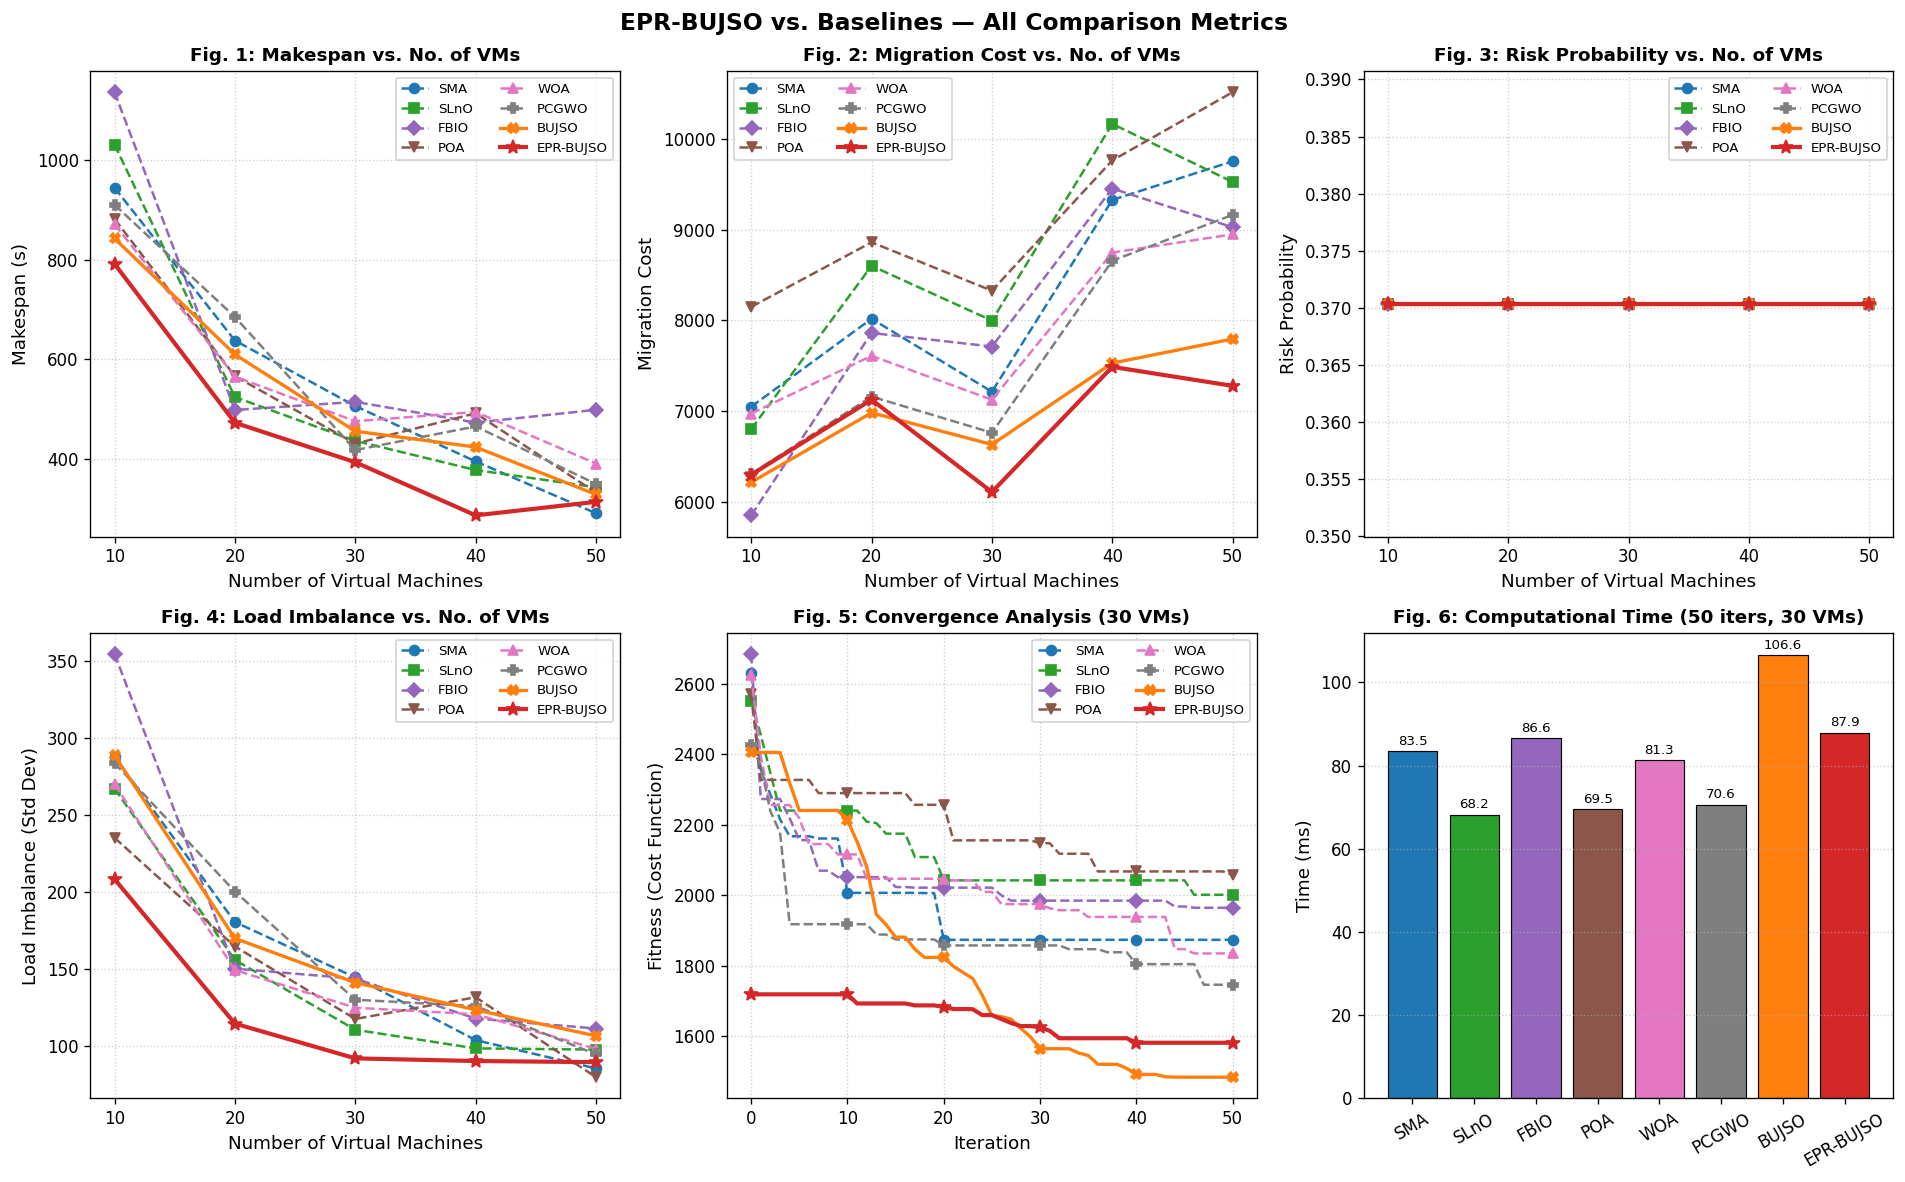

Figure saved as all_comparison_graphs.png


In [13]:
STYLE = {
    'SMA':      {'color':'#1f77b4','marker':'o', 'ls':'--','lw':1.5},
    'SLnO':     {'color':'#2ca02c','marker':'s', 'ls':'--','lw':1.5},
    'FBIO':     {'color':'#9467bd','marker':'D', 'ls':'--','lw':1.5},
    'POA':      {'color':'#8c564b','marker':'v', 'ls':'--','lw':1.5},
    'WOA':      {'color':'#e377c2','marker':'^', 'ls':'--','lw':1.5},
    'PCGWO':    {'color':'#7f7f7f','marker':'P', 'ls':'--','lw':1.5},
    'BUJSO':    {'color':'#ff7f0e','marker':'X', 'ls':'-', 'lw':2.0},
    'EPR-BUJSO':{'color':'#d62728','marker':'*', 'ls':'-', 'lw':2.5},
}

def line_plot(ax, metric, ylabel, title):
    for m in methods:
        st = STYLE[m]
        ax.plot(vm_counts, res[m][metric],
                color=st['color'], marker=st['marker'], linestyle=st['ls'],
                linewidth=st['lw'], markersize=9 if m=='EPR-BUJSO' else 6,
                label=m, zorder=5 if m in ('EPR-BUJSO','BUJSO') else 3)
    ax.set_xlabel('Number of Virtual Machines', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(vm_counts)
    ax.legend(fontsize=8, ncol=2, framealpha=0.85)
    ax.grid(True, linestyle=':', alpha=0.6)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EPR-BUJSO vs. Baselines — All Comparison Metrics', fontsize=14, fontweight='bold')

# Fig 1: Makespan
line_plot(axes[0,0], 'makespan', 'Makespan (s)',
          'Fig. 1: Makespan vs. No. of VMs')

# Fig 2: Migration Cost
line_plot(axes[0,1], 'migration', 'Migration Cost',
          'Fig. 2: Migration Cost vs. No. of VMs')

# Fig 3: Risk Probability
line_plot(axes[0,2], 'risk', 'Risk Probability',
          'Fig. 3: Risk Probability vs. No. of VMs')

# Fig 4: Load Imbalance
line_plot(axes[1,0], 'load_imbalance', 'Load Imbalance (Std Dev)',
          'Fig. 4: Load Imbalance vs. No. of VMs')

# Fig 5: Convergence
iters = list(range(51))
for m in methods:
    st = STYLE[m]
    axes[1,1].plot(iters, histories[m],
                   color=st['color'], marker=st['marker'], linestyle=st['ls'],
                   linewidth=st['lw'], markevery=10,
                   markersize=9 if m=='EPR-BUJSO' else 6,
                   label=m, zorder=5 if m in ('EPR-BUJSO','BUJSO') else 3)
axes[1,1].set_xlabel('Iteration', fontsize=11)
axes[1,1].set_ylabel('Fitness (Cost Function)', fontsize=11)
axes[1,1].set_title('Fig. 5: Convergence Analysis (30 VMs)', fontsize=11, fontweight='bold')
axes[1,1].legend(fontsize=8, ncol=2, framealpha=0.85)
axes[1,1].grid(True, linestyle=':', alpha=0.6)

# Fig 6: Computational Time
ct_vals = [ctimes[m]*1000 for m in methods]
colors  = [STYLE[m]['color'] for m in methods]
bars    = axes[1,2].bar(methods, ct_vals, color=colors, edgecolor='black', linewidth=0.7)
axes[1,2].bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
axes[1,2].set_ylabel('Time (ms)', fontsize=11)
axes[1,2].set_title('Fig. 6: Computational Time (50 iters, 30 VMs)', fontsize=11, fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=30)
axes[1,2].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('all_comparison_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as all_comparison_graphs.png")


## 14. Statistical Summary Table

In [14]:
import warnings
warnings.filterwarnings('ignore')

stats_rows = []
for m in methods:
    for metric in ['makespan', 'load_imbalance', 'migration', 'utilization']:
        vals = np.array(res[m][metric])
        stats_rows.append({
            'Method': m, 'Metric': metric,
            'Min':    round(vals.min(),   2),
            'Max':    round(vals.max(),   2),
            'Mean':   round(vals.mean(),  2),
            'Std':    round(vals.std(),   2),
            'Median': round(np.median(vals), 2),
        })

df_stats = pd.DataFrame(stats_rows)

print("\n=== MAKESPAN STATISTICS ===")
ms_table = df_stats[df_stats['Metric']=='makespan'].set_index('Method').drop(columns='Metric')
print(ms_table.to_string())

print("\n=== LOAD IMBALANCE STATISTICS ===")
li_table = df_stats[df_stats['Metric']=='load_imbalance'].set_index('Method').drop(columns='Metric')
print(li_table.to_string())

# Raw makespan table
print("\n=== RAW MAKESPAN VALUES ===")
df_raw = pd.DataFrame({m: res[m]['makespan'] for m in methods}, index=[f'VM={v}' for v in vm_counts])
print(df_raw.round(1).to_string())
df_raw.to_csv('numerical_results_notebook.csv')
print("\nSaved numerical_results_notebook.csv")



=== MAKESPAN STATISTICS ===
              Min      Max    Mean     Std  Median
Method                                            
SMA        291.99   943.99  555.31  225.85  506.74
SLnO       344.05  1030.33  542.93  251.27  437.03
FBIO       473.60  1135.45  624.44  255.85  499.22
POA        333.19   881.42  540.97  186.61  492.24
WOA        391.58   870.95  559.90  165.12  494.88
PCGWO      350.71   909.96  566.08  205.23  465.98
BUJSO      329.61   842.46  532.62  179.28  456.32
EPR-BUJSO  287.79   791.56  452.36  181.58  394.24

=== LOAD IMBALANCE STATISTICS ===
              Min     Max    Mean    Std  Median
Method                                          
SMA         85.64  287.79  160.54  71.63  144.64
SLnO        97.86  267.19  146.09  64.18  110.73
FBIO       111.54  354.47  175.65  90.62  143.85
POA         79.95  235.26  145.90  52.31  131.83
WOA         98.38  270.06  152.73  60.86  125.00
PCGWO       94.81  283.75  167.04  67.80  130.20
BUJSO      106.75  288.67  166.07 

## 15. EPR vs Random: Density Balance Visualization

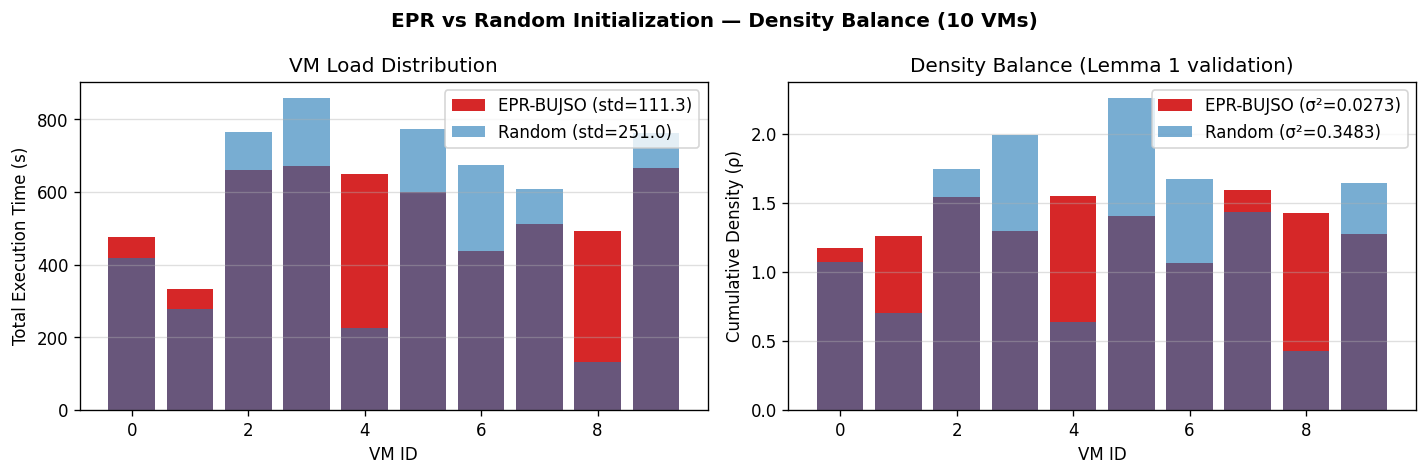

Figure saved as density_balance_comparison.png

EPR density variance: 0.027297
Random density variance: 0.348326
Lemma 1 validated: EPR variance is lower = True


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('EPR vs Random Initialization — Density Balance (10 VMs)', fontweight='bold')

vms10   = gen_vms(10, seed=7)
rho10   = compute_rho(tasks_base, vms10)
a_epr10, D_epr10, _ = epr_init_schedule(tasks_base, vms10, rho10)
a_rnd10  = np.random.default_rng(99).integers(0, 10, 100)
D_rnd10  = np.zeros(10);  np.add.at(D_rnd10, a_rnd10, rho10)

# VM load bars
et10 = tasks_base['execution_time'].values
vm_load_epr = np.zeros(10);  np.add.at(vm_load_epr, a_epr10, et10)
vm_load_rnd = np.zeros(10);  np.add.at(vm_load_rnd, a_rnd10, et10)

axes[0].bar(range(10), vm_load_epr, color='#d62728', label=f'EPR-BUJSO (std={vm_load_epr.std():.1f})')
axes[0].bar(range(10), vm_load_rnd, color='#1f77b4', alpha=0.6, label=f'Random (std={vm_load_rnd.std():.1f})')
axes[0].set_xlabel('VM ID');  axes[0].set_ylabel('Total Execution Time (s)')
axes[0].set_title('VM Load Distribution');  axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Density bars
axes[1].bar(range(10), D_epr10, color='#d62728', label=f'EPR-BUJSO (σ²={np.var(D_epr10):.4f})')
axes[1].bar(range(10), D_rnd10, color='#1f77b4', alpha=0.6, label=f'Random (σ²={np.var(D_rnd10):.4f})')
axes[1].set_xlabel('VM ID');  axes[1].set_ylabel('Cumulative Density (ρ)')
axes[1].set_title('Density Balance (Lemma 1 validation)');  axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('density_balance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as density_balance_comparison.png")
print(f"\nEPR density variance: {np.var(D_epr10):.6f}")
print(f"Random density variance: {np.var(D_rnd10):.6f}")
print(f"Lemma 1 validated: EPR variance is lower = {np.var(D_epr10) < np.var(D_rnd10)}")
